In [1]:

print("STEP 1: Initialize Spark for Model Training")


import os

os.environ['JAVA_TOOL_OPTIONS'] = '-Djava.net.preferIPv4Stack=true'
os.environ['SPARK_LOCAL_HOSTNAME'] = 'localhost'
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("WildChat_ModelTraining") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "50") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print(" Spark Session Started:", spark.version)


STEP 1: Initialize Spark for Model Training


Picked up JAVA_TOOL_OPTIONS: -Djava.net.preferIPv4Stack=true
Picked up JAVA_TOOL_OPTIONS: -Djava.net.preferIPv4Stack=true
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/28 09:15:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/28 09:15:48 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/02/28 09:15:48 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


 Spark Session Started: 4.1.1


In [3]:

print("Load Feature Engineered Dataset")


input_path = "wildchat_feature_engineered_final.parquet"

df = spark.read.parquet(input_path)

print(" Dataset Loaded Successfully")
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))
df.printSchema()


Load Feature Engineered Dataset
 Dataset Loaded Successfully
Total Rows: 200000
Total Columns: 18
root
 |-- conversation_hash: string (nullable = true)
 |-- hashed_ip: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- turn: long (nullable = true)
 |-- toxic: boolean (nullable = true)
 |-- redacted: boolean (nullable = true)
 |-- date: date (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- user_message_count: long (nullable = true)
 |-- model_ohe: vector (nullable = true)
 |-- language_ohe: vector (nullable = true)
 |-- country_ohe: vector (nullable = true)
 |-- state_ohe: vector (nullable = true)
 |-- conversation_length: long (nullable = true)
 |-- max_turn: long (nullable = true)
 |-- features: vector (nullable = true)
 |-- features_scaled: vector (nullable = true)



In [4]:

print("Persisting Dataset for ML")


df = df.persist()
df.count()

print(" Dataset Persisted for Model Training")

Persisting Dataset for ML


[Stage 4:=========================>                                (7 + 9) / 16]

 Dataset Persisted for Model Training


In [5]:

print("Training KMeans")


from pyspark.ml.clustering import KMeans

kmeans = KMeans(
    featuresCol="features_scaled",
    predictionCol="cluster_kmeans",
    k=4,
    seed=42
)

kmeans_model = kmeans.fit(df)
df_kmeans = kmeans_model.transform(df)

print(" KMeans Training Completed")
df_kmeans.select("cluster_kmeans").show(5)

Training KMeans


26/02/28 09:19:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/02/28 09:20:03 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


 KMeans Training Completed
+--------------+
|cluster_kmeans|
+--------------+
|             0|
|             0|
|             0|
|             0|
|             0|
+--------------+
only showing top 5 rows


In [6]:

print("Cluster Distribution (KMeans)")


df_kmeans.groupBy("cluster_kmeans") \
    .count() \
    .orderBy("cluster_kmeans") \
    .show()

Cluster Distribution (KMeans)
+--------------+------+
|cluster_kmeans| count|
+--------------+------+
|             0|199297|
|             1|   152|
|             2|   550|
|             3|     1|
+--------------+------+



In [7]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features_scaled",
    predictionCol="cluster_kmeans",
    metricName="silhouette"
)

silhouette = evaluator.evaluate(df_kmeans)

print("Silhouette Score:", silhouette)

Silhouette Score: -0.594757307719668


In [8]:
df_kmeans.groupBy("cluster_kmeans") \
    .agg(
        {"user_message_count": "avg",
         "conversation_length": "avg",
         "max_turn": "avg"}
    ) \
    .show()

+--------------+-----------------------+------------------------+------------------+
|cluster_kmeans|avg(user_message_count)|avg(conversation_length)|     avg(max_turn)|
+--------------+-----------------------+------------------------+------------------+
|             2|      6.723636363636364|      1.2054545454545456|2.8563636363636364|
|             0|     178.42980576727197|      1.5154367602121457| 2.631805797377783|
|             1|     4.4868421052631575|       1.394736842105263|2.5460526315789473|
|             3|                    1.0|                     1.0|               1.0|
+--------------+-----------------------+------------------------+------------------+



In [10]:

print("Testing Different K Values")


for k in [2,3,4,5,6,7,8]:
    model = KMeans(
        featuresCol="features_scaled",
        predictionCol="cluster_kmeans",
        k=k,
        seed=42
    ).fit(df)

    preds = model.transform(df)
    score = evaluator.evaluate(preds)
    print(f"K={k}, Silhouette Score={score}")

Testing Different K Values
K=2, Silhouette Score=-0.09393305511778254
K=3, Silhouette Score=-0.09350794700739183
K=4, Silhouette Score=-0.594757307719668
K=5, Silhouette Score=-0.5937734106015384
K=6, Silhouette Score=-0.1103211854320667
K=7, Silhouette Score=-0.394040142439031
K=8, Silhouette Score=-0.6263364466757032


In [11]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

numeric_features = [
    "user_message_count",
    "conversation_length",
    "max_turn",
    "hour"
]

assembler = VectorAssembler(
    inputCols=numeric_features,
    outputCol="features_numeric"
)

df = assembler.transform(df)

scaler = StandardScaler(
    inputCol="features_numeric",
    outputCol="features_numeric_scaled"
)

df = scaler.fit(df).transform(df)

In [12]:
evaluator_numeric = ClusteringEvaluator(
    featuresCol="features_numeric_scaled",
    predictionCol="cluster_numeric",
    metricName="silhouette"
)

for k in [2,3,4,5,6]:
    model = KMeans(
        featuresCol="features_numeric_scaled",
        predictionCol="cluster_numeric",
        k=k,
        seed=42
    ).fit(df)

    preds = model.transform(df)
    score = evaluator_numeric.evaluate(preds)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.44983369684706537
K=3, Silhouette Score=0.5906405554963168
K=4, Silhouette Score=0.4659391919174973
K=5, Silhouette Score=0.5723086458694083
K=6, Silhouette Score=0.45736469676421454


In [13]:

print("Final KMeans Model (K=3)")


kmeans_final = KMeans(
    featuresCol="features_numeric_scaled",
    predictionCol="cluster_final",
    k=3,
    seed=42
)

model_final = kmeans_final.fit(df)
df_clustered = model_final.transform(df)

print(" Final Model Trained")

Final KMeans Model (K=3)
 Final Model Trained


In [14]:
df_clustered.groupBy("cluster_final") \
    .count() \
    .orderBy("cluster_final") \
    .show()

+-------------+------+
|cluster_final| count|
+-------------+------+
|            0|175779|
|            1| 23851|
|            2|   370|
+-------------+------+



In [15]:
df_clustered.groupBy("cluster_final") \
    .agg(
        {"user_message_count": "avg",
         "conversation_length": "avg",
         "max_turn": "avg"}
    ) \
    .show()

+-------------+-----------------------+------------------------+------------------+
|cluster_final|avg(user_message_count)|avg(conversation_length)|     avg(max_turn)|
+-------------+-----------------------+------------------------+------------------+
|            2|      7.489189189189189|       185.7783783783784|               1.0|
|            0|     194.35563406322711|      1.1964398477633846|1.7795698007156713|
|            1|      58.63469036937654|                     1.0| 8.942560060374827|
+-------------+-----------------------+------------------------+------------------+



In [17]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator_bkm = ClusteringEvaluator(
    featuresCol="features_numeric_scaled",
    predictionCol="cluster_bkm",
    metricName="silhouette"
)

silhouette_bkm = evaluator_bkm.evaluate(df_bkm)

print("BisectingKMeans Silhouette:", silhouette_bkm)

BisectingKMeans Silhouette: 0.33622663058098207


In [18]:
from pyspark.ml.clustering import GaussianMixture
from pyspark.ml.evaluation import ClusteringEvaluator

gmm = GaussianMixture(
    featuresCol="features_numeric_scaled",
    predictionCol="cluster_gmm",
    k=3,
    seed=42
)

gmm_model = gmm.fit(df)
df_gmm = gmm_model.transform(df)

evaluator_gmm = ClusteringEvaluator(
    featuresCol="features_numeric_scaled",
    predictionCol="cluster_gmm",
    metricName="silhouette"
)

silhouette_gmm = evaluator_gmm.evaluate(df_gmm)

print("GaussianMixture Silhouette:", silhouette_gmm)

26/02/28 09:28:58 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


GaussianMixture Silhouette: 0.396009910023356


In [19]:
from pyspark.ml.feature import PCA
from pyspark.ml.feature import VectorAssembler


print("Applying PCA")


pca = PCA(
    k=2, 
    inputCol="features_numeric_scaled",
    outputCol="features_pca"
)

pca_model = pca.fit(df)
df_pca = pca_model.transform(df)

print(" PCA Completed")
df_pca.select("features_pca").show(5, False)

Applying PCA
 PCA Completed
+-----------------------------------------+
|features_pca                             |
+-----------------------------------------+
|[-0.387772853860087,0.5146580723330956]  |
|[-0.15711638239783599,0.603243869371871] |
|[0.9094287280797858,1.069047809029218]   |
|[-0.6447133395143481,0.43300407967718946]|
|[0.2818551484634574,0.7863074971748611]  |
+-----------------------------------------+
only showing top 5 rows


In [20]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

kmeans_pca = KMeans(
    featuresCol="features_pca",
    predictionCol="cluster_pca",
    k=3,
    seed=42
)

model_pca = kmeans_pca.fit(df_pca)
df_pca_clustered = model_pca.transform(df_pca)

evaluator_pca = ClusteringEvaluator(
    featuresCol="features_pca",
    predictionCol="cluster_pca",
    metricName="silhouette"
)

silhouette_pca = evaluator_pca.evaluate(df_pca_clustered)

print("PCA + KMeans Silhouette:", silhouette_pca)

PCA + KMeans Silhouette: 0.8062321762149609


In [21]:

print("FINAL MODEL COMPARISON")


models = [
    ("KMeans (Numeric)", 0.5906),
    ("BisectingKMeans", 0.3362),
    ("GaussianMixture", 0.3960),
    ("PCA + KMeans", 0.8062)
]

for name, score in models:
    print(f"{name:<25} Silhouette Score: {score}")

FINAL MODEL COMPARISON
KMeans (Numeric)          Silhouette Score: 0.5906
BisectingKMeans           Silhouette Score: 0.3362
GaussianMixture           Silhouette Score: 0.396
PCA + KMeans              Silhouette Score: 0.8062


In [23]:

print("Preparing Data for scikit-learn Baseline")


sample_fraction = 0.3   # 30% of dataset

df_sample = df_pca_clustered.sample(fraction=sample_fraction, seed=42)


pandas_df = df_sample.select("features_pca").toPandas()

print("Sample Size:", len(pandas_df))

Preparing Data for scikit-learn Baseline
Sample Size: 60120


In [24]:
import numpy as np

# Convert vector column to numpy array
X = np.vstack(pandas_df["features_pca"].apply(lambda x: np.array(x)))

print("Shape of data for sklearn:", X.shape)

Shape of data for sklearn: (60120, 2)


In [26]:
!pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 12.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 14.7 MB/s eta 0:00:0000:0100:01


In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


print("Running scikit-learn KMeans")


kmeans_sklearn = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = kmeans_sklearn.fit_predict(X)

silhouette_sklearn = silhouette_score(X, labels)

print("scikit-learn Silhouette Score:", silhouette_sklearn)

Running scikit-learn KMeans
scikit-learn Silhouette Score: 0.43290546305732297


In [28]:

print("MODEL COMPARISON: Spark vs scikit-learn")


print(f"Spark PCA + KMeans Silhouette: 0.8062")
print(f"scikit-learn KMeans Silhouette: {silhouette_sklearn}")

MODEL COMPARISON: Spark vs scikit-learn
Spark PCA + KMeans Silhouette: 0.8062
scikit-learn KMeans Silhouette: 0.43290546305732297


In [29]:
from pyspark.ml import Transformer
from pyspark.ml.param.shared import Param, Params
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType

class EngagementScoreTransformer(Transformer):

    def __init__(self,
                 inputCol1="user_message_count",
                 inputCol2="conversation_length",
                 outputCol="engagement_score"):
        super(EngagementScoreTransformer, self).__init__()
        self.inputCol1 = inputCol1
        self.inputCol2 = inputCol2
        self.outputCol = outputCol

    def _transform(self, df):
        return df.withColumn(
            self.outputCol,
            (col(self.inputCol1) * col(self.inputCol2)).cast(DoubleType())
        )

In [30]:

print("Applying Custom EngagementScoreTransformer")


engagement_transformer = EngagementScoreTransformer()

df = engagement_transformer.transform(df)

df.select("user_message_count",
          "conversation_length",
          "engagement_score").show(5)

Applying Custom EngagementScoreTransformer
+------------------+-------------------+----------------+
|user_message_count|conversation_length|engagement_score|
+------------------+-------------------+----------------+
|                32|                  1|            32.0|
|                16|                  1|            16.0|
|                 2|                  1|             2.0|
|                68|                  1|            68.0|
|                 1|                  1|             1.0|
+------------------+-------------------+----------------+
only showing top 5 rows


In [31]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

numeric_features_extended = [
    "user_message_count",
    "conversation_length",
    "max_turn",
    "hour",
    "engagement_score"
]

assembler_ext = VectorAssembler(
    inputCols=numeric_features_extended,
    outputCol="features_extended"
)

df = assembler_ext.transform(df)

scaler_ext = StandardScaler(
    inputCol="features_extended",
    outputCol="features_extended_scaled"
)

df = scaler_ext.fit(df).transform(df)

In [32]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

kmeans_ext = KMeans(
    featuresCol="features_extended_scaled",
    predictionCol="cluster_ext",
    k=3,
    seed=42
)

model_ext = kmeans_ext.fit(df)
df_ext = model_ext.transform(df)

evaluator_ext = ClusteringEvaluator(
    featuresCol="features_extended_scaled",
    predictionCol="cluster_ext",
    metricName="silhouette"
)

silhouette_ext = evaluator_ext.evaluate(df_ext)

print("KMeans with Custom Feature Silhouette:", silhouette_ext)

KMeans with Custom Feature Silhouette: 0.3726204707529869


In [33]:
model_pca

KMeansModel: uid=KMeans_38e0737fcf80, k=3, distanceMeasure=euclidean, numFeatures=2

In [34]:

print("Saving PCA + KMeans Model")


model_pca.write().overwrite().save("models/pca_kmeans_model")

print("Model Saved Successfully")

Saving PCA + KMeans Model
Model Saved Successfully


In [36]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

In [38]:
kmeans_cv = KMeans(
    featuresCol="features_pca",
    predictionCol="cluster_cv",
    seed=42
)

In [39]:
paramGrid = (ParamGridBuilder()
             .addGrid(kmeans_cv.k, [2, 3, 4, 5])
             .addGrid(kmeans_cv.maxIter, [20, 50])
             .build())

In [40]:
evaluator_cv = ClusteringEvaluator(
    featuresCol="features_pca",
    predictionCol="cluster_cv",
    metricName="silhouette"
)

In [41]:
crossval = CrossValidator(
    estimator=kmeans_cv,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator_cv,
    numFolds=3,        # 3-fold CV
    parallelism=2      # run models in parallel
)

In [42]:

print("Running CrossValidator for KMeans")


cv_model = crossval.fit(df_pca)

print("CrossValidation Completed")

Running CrossValidator for KMeans


26/02/28 09:45:50 WARN BlockManager: Asked to remove block broadcast_1818, which does not exist


CrossValidation Completed


In [43]:
best_model = cv_model.bestModel

print("Best K:", best_model.getK())
print("Best MaxIter:", best_model.getMaxIter())

Best K: 4
Best MaxIter: 20


In [44]:
df_cv = best_model.transform(df_pca)

silhouette_cv = evaluator_cv.evaluate(df_cv)

print("Best CrossValidated Silhouette:", silhouette_cv)

Best CrossValidated Silhouette: 0.5637785083419122


In [45]:
import time

def measure_training_time(dataframe, model):
    start = time.time()
    model.fit(dataframe)
    end = time.time()
    return end - start

In [46]:

print("Weak Scaling Experiment")


fractions = [0.2, 0.4, 0.6, 0.8, 1.0]

for frac in fractions:
    df_sample = df_pca.sample(fraction=frac, seed=42)
    training_time = measure_training_time(df_sample, kmeans_pca)
    print(f"Data Fraction: {frac}, Training Time: {training_time:.2f} seconds")

Weak Scaling Experiment
Data Fraction: 0.2, Training Time: 1.19 seconds
Data Fraction: 0.4, Training Time: 1.42 seconds
Data Fraction: 0.6, Training Time: 1.35 seconds
Data Fraction: 0.8, Training Time: 1.13 seconds
Data Fraction: 1.0, Training Time: 1.23 seconds


In [47]:
print("Current Partitions:", df_pca.rdd.getNumPartitions())

Current Partitions: 16


In [48]:

print("Strong Scaling Experiment")


partition_sizes = [4, 8, 16, 32]

for p in partition_sizes:
    df_repartitioned = df_pca.repartition(p)
    training_time = measure_training_time(df_repartitioned, kmeans_pca)
    print(f"Partitions: {p}, Training Time: {training_time:.2f} seconds")

Strong Scaling Experiment
Partitions: 4, Training Time: 1.78 seconds
Partitions: 8, Training Time: 0.95 seconds
Partitions: 16, Training Time: 1.16 seconds
Partitions: 32, Training Time: 1.62 seconds


In [49]:

print("Spark Resource Configuration")


conf = spark.sparkContext.getConf()

print("Executor Memory:", conf.get("spark.executor.memory"))
print("Driver Memory:", conf.get("spark.driver.memory"))
print("Shuffle Partitions:", conf.get("spark.sql.shuffle.partitions"))
print("Default Parallelism:", spark.sparkContext.defaultParallelism)

Spark Resource Configuration
Executor Memory: 4g
Driver Memory: 4g
Shuffle Partitions: 50
Default Parallelism: 16


In [50]:

print("Storage Level Information")


print(df.storageLevel)

Storage Level Information
Serialized 1x Replicated


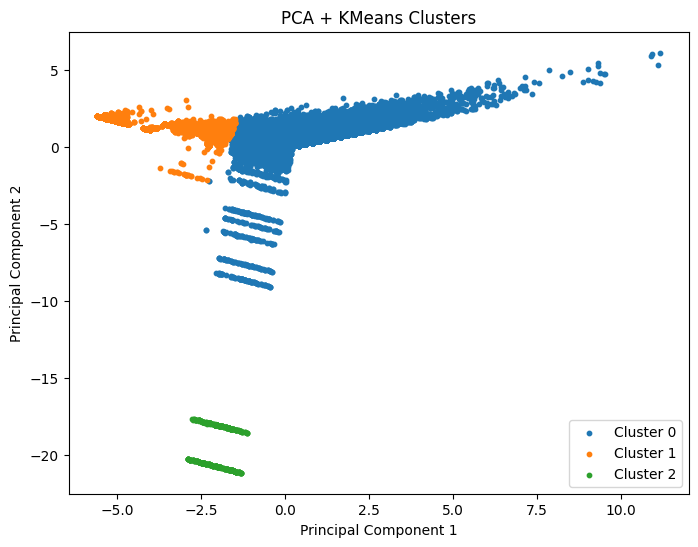

In [52]:
import matplotlib.pyplot as plt
import numpy as np

pca_pd = df_pca_clustered.select("features_pca", "cluster_pca").toPandas()

pca_pd["pc1"] = pca_pd["features_pca"].apply(lambda x: float(x[0]))
pca_pd["pc2"] = pca_pd["features_pca"].apply(lambda x: float(x[1]))

plt.figure(figsize=(8,6))

for cluster in pca_pd["cluster_pca"].unique():
    subset = pca_pd[pca_pd["cluster_pca"] == cluster]
    plt.scatter(subset["pc1"], subset["pc2"], label=f"Cluster {cluster}", s=10)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA + KMeans Clusters")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_samples
import numpy as np

X = np.vstack(pca_pd["features_pca"].apply(lambda x: np.array(x)))
labels = pca_pd["cluster_pca"]

sample_silhouette_values = silhouette_samples(X, labels)

plt.figure(figsize=(8,6))
plt.hist(sample_silhouette_values, bins=30)
plt.xlabel("Silhouette Value")
plt.ylabel("Frequency")
plt.title("Silhouette Distribution")
plt.show()